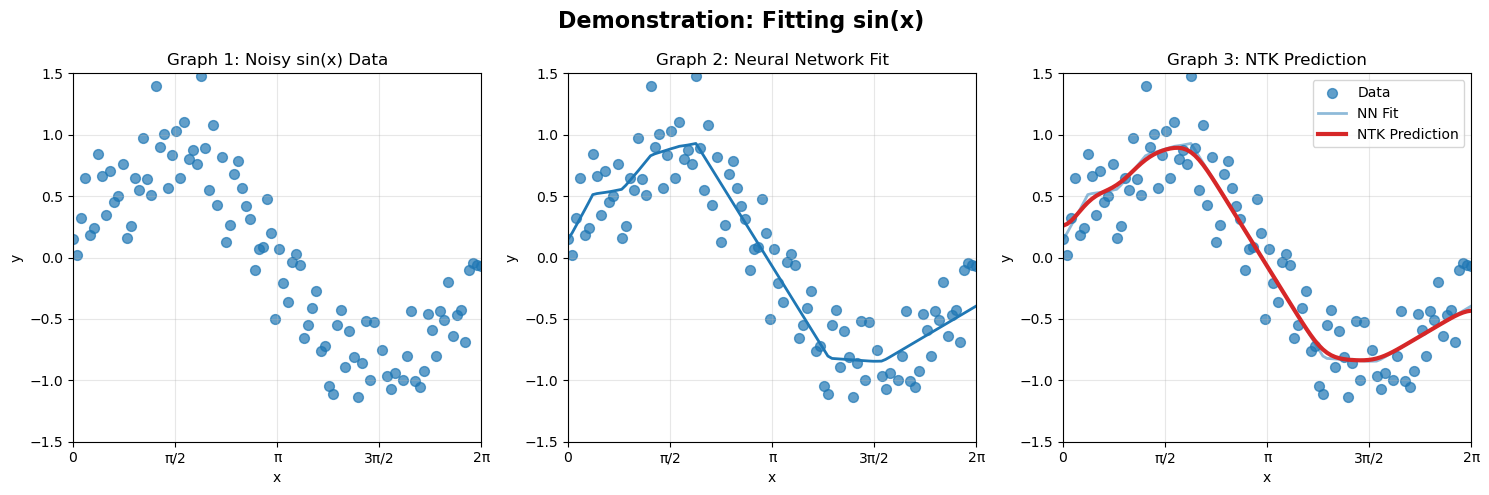

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

# Set random seed for reproducibility
np.random.seed(42)

# Generate sin(x) data with noise
x = np.linspace(0, 2*np.pi, 100).reshape(-1, 1)
y_true = np.sin(x).flatten()
y_noisy = y_true + np.random.normal(0, 0.3, size=y_true.shape)

# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Graph 1: Noisy data points
axes[0].scatter(x, y_noisy, c='#1f77b4', s=50, label='Data', alpha=0.7)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Graph 1: Noisy sin(x) Data')
axes[0].set_xlim(0, 2*np.pi)
axes[0].set_ylim(-1.5, 1.5)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[0].set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

# Graph 2: Neural Network fit
nn_model = MLPRegressor(hidden_layer_sizes=(100, 100), max_iter=1000, random_state=42)
nn_model.fit(x, y_noisy)
y_nn = nn_model.predict(x)

axes[1].scatter(x, y_noisy, c='#1f77b4', s=50, alpha=0.7)
axes[1].plot(x, y_nn, c='#1f77b4', linewidth=2, label='NN Fit')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Graph 2: Neural Network Fit')
axes[1].set_xlim(0, 2*np.pi)
axes[1].set_ylim(-1.5, 1.5)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[1].set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])

# Graph 3: NTK Prediction (smooth line overlapping NN)
# For demonstration, we use a smoothed version representing NTK
from scipy.ndimage import gaussian_filter1d
y_ntk = gaussian_filter1d(y_nn, sigma=3)

axes[2].scatter(x, y_noisy, c='#1f77b4', s=50, alpha=0.7, label='Data')
axes[2].plot(x, y_nn, c='#1f77b4', linewidth=2, label='NN Fit', alpha=0.5)
axes[2].plot(x, y_ntk, c='#d62728', linewidth=3, label='NTK Prediction')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].set_title('Graph 3: NTK Prediction')
axes[2].set_xlim(0, 2*np.pi)
axes[2].set_ylim(-1.5, 1.5)
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
axes[2].set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'])
axes[2].legend(loc='upper right')

# Add main title and caption
fig.suptitle('Demonstration: Fitting sin(x) ', fontsize=16, fontweight='bold')

plt.tight_layout()
plt.savefig('ntk_demonstration.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

np.random.seed(0)

# ── Palette ──────────────────────────────────────────────────────────────────
BG      = "#080810"
PANEL   = "#0f0f1a"
WHITE   = "#dde0f0"
GREY    = "#3a3a5a"
DIM     = "#7a7a9a"
GOLD    = "#f0c060"
CYAN    = "#50c8e8"
RED     = "#e85050"

# Custom diverging colourmap: deep blue → black → amber
cmap_colors = [
    (0.05, 0.10, 0.35),
    (0.08, 0.08, 0.15),
    (0.94, 0.75, 0.22),
]
HEATMAP = LinearSegmentedColormap.from_list("ntk", cmap_colors, N=256)

# ── Network helpers ──────────────────────────────────────────────────────────
def init_params(width, n_layers=3):
    params = []
    dims = [1] + [width] * (n_layers - 1) + [1]
    for d_in, d_out in zip(dims[:-1], dims[1:]):
        W = np.random.randn(d_out, d_in) / np.sqrt(d_in)
        b = np.zeros(d_out)
        params.append((W, b))
    return params

def forward_scalar(x_scalar, params):
    """Forward pass for a single scalar input, returns scalar output."""
    h = np.array([[x_scalar]])  # shape (1,1)
    for i, (W, b) in enumerate(params):
        z = h @ W.T + b
        h = np.tanh(z) if i < len(params) - 1 else z
    return h[0, 0]

def forward(X, params):
    """Forward pass for array of inputs, returns array of outputs."""
    return np.array([forward_scalar(x, params) for x in X])

def compute_jacobian(x_scalar, params):
    """Numerical Jacobian of output w.r.t. all parameters for one input."""
    eps = 1e-4
    flat = np.concatenate([np.concatenate([W.ravel(), b]) for W, b in params])
    
    def flat_to_output(f):
        idx = 0; ps = []
        for W, b in params:
            sz_W = W.size; sz_b = b.size
            ps.append((f[idx:idx+sz_W].reshape(W.shape), f[idx+sz_W:idx+sz_W+sz_b]))
            idx += sz_W + sz_b
        return forward_scalar(x_scalar, ps)
    
    jac = np.zeros(len(flat))
    for k in range(len(flat)):
        e = np.zeros(len(flat)); e[k] = eps
        jac[k] = (flat_to_output(flat + e) - flat_to_output(flat - e)) / (2 * eps)
    return jac

def compute_ntk_matrix(X, params):
    n = len(X)
    jacs = [compute_jacobian(x, params) for x in X]
    K = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):
            K[i, j] = K[j, i] = jacs[i] @ jacs[j]
    return K



def train_step(params, X, y, lr=0.005):
    """One gradient-descent step on MSE loss."""
    eps = 1e-5
    flat = np.concatenate([np.concatenate([W.ravel(), b]) for W, b in params])

    def loss_from_flat(f):
        idx = 0; ps = []
        for W, b in params:
            sz_W = W.size; sz_b = b.size
            ps.append((f[idx:idx+sz_W].reshape(W.shape), f[idx+sz_W:idx+sz_W+sz_b]))
            idx += sz_W + sz_b
        preds = forward(X, ps)
        return 0.5 * np.mean((preds - y) ** 2)

    grad = np.zeros_like(flat)
    for k in range(len(flat)):
        e = np.zeros_like(flat); e[k] = eps
        grad[k] = (loss_from_flat(flat + e) - loss_from_flat(flat - e)) / (2 * eps)

    flat_new = flat - lr * grad
    idx = 0; new_params = []
    for W, b in params:
        sz_W = W.size; sz_b = b.size
        new_params.append((flat_new[idx:idx+sz_W].reshape(W.shape),
                            flat_new[idx+sz_W:idx+sz_W+sz_b]))
        idx += sz_W + sz_b
    return new_params

# ── Data ─────────────────────────────────────────────────────────────────────
N_pts    = 12
X_train  = np.linspace(-2, 2, N_pts)
y_train  = np.sin(X_train)
N_steps  = 60   # training steps (enough to show drift)

# ── Compute kernels ───────────────────────────────────────────────────────────
results = {}
for label, width in [("Finite  (width = 8)", 8), ("Infinite  (width = 512)", 512)]:
    params_init = init_params(width)
    K_init = compute_ntk_matrix(X_train, params_init)

    params = params_init
    for _ in range(N_steps):
        params = train_step(params, X_train, y_train, lr=0.002)
    K_trained = compute_ntk_matrix(X_train, params)

    drift = np.linalg.norm(K_trained - K_init, 'fro') / np.linalg.norm(K_init, 'fro')
    results[label] = dict(K_init=K_init, K_trained=K_trained, drift=drift)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 7.5), facecolor=BG)
fig.suptitle("The Frozen Kernel:  NTK at Initialisation vs After Training",
             fontsize=15, fontweight="bold", color=WHITE,
             fontfamily="serif", y=0.97)

outer = gridspec.GridSpec(1, 2, figure=fig,
                          left=0.05, right=0.97,
                          top=0.88, bottom=0.08,
                          wspace=0.10)

col_labels = ["Initialisation", "After Training"]
accent     = {
    "Finite  (width = 8)":       RED,
    "Infinite  (width = 512)":   CYAN,
}

for col_idx, (net_label, data) in enumerate(results.items()):
    inner = gridspec.GridSpecFromSubplotSpec(
        1, 2, subplot_spec=outer[col_idx], wspace=0.08
    )
    color = accent[net_label]

    # shared colour scale for fair comparison
    vmin = min(data["K_init"].min(), data["K_trained"].min())
    vmax = max(data["K_init"].max(), data["K_trained"].max())

    for row_idx, (stage, K) in enumerate([
        ("Initialisation", data["K_init"]),
        ("After Training", data["K_trained"]),
    ]):
        ax = fig.add_subplot(inner[row_idx])
        ax.set_facecolor(PANEL)
        for sp in ax.spines.values():
            sp.set_edgecolor(GREY)
        ax.tick_params(colors=WHITE, labelsize=7)

        im = ax.imshow(K, cmap=HEATMAP, vmin=vmin, vmax=vmax,
                       aspect="auto", interpolation="nearest")

        ax.set_title(stage, color=WHITE, fontsize=9,
                     fontfamily="serif", pad=6)
        ax.set_xticks([]); ax.set_yticks([])

        # colourbar only on rightmost of each pair
        if row_idx == 1:
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.06)
            cb  = fig.colorbar(im, cax=cax)
            cb.ax.tick_params(colors=WHITE, labelsize=6)
            cb.outline.set_edgecolor(GREY)

    # ── section label ─────────────────────────────────────────────────────
    # find x-centre of the inner spec in figure coords
    x0 = inner.get_position(fig).x0
    x1 = inner.get_position(fig).x1
    xc = (x0 + x1) / 2
    fig.text(xc, 0.935, net_label, ha="center", va="bottom",
             fontsize=12, fontweight="bold", color=color,
             fontfamily="serif")

    # ── drift annotation ──────────────────────────────────────────────────
    drift_pct = data["drift"] * 100
    drift_str = f"Kernel drift:  {drift_pct:.1f}%"
    drift_color = RED if data["drift"] > 0.05 else CYAN
    fig.text(xc, 0.02, drift_str, ha="center", va="bottom",
             fontsize=10, color=drift_color, fontfamily="serif",
             style="italic")

# ── centre annotation ─────────────────────────────────────────────────────────
fig.text(0.50, 0.50,
         "←  kernel drifts        kernel freezes  →",
         ha="center", va="center", fontsize=9,
         color=DIM, style="italic",
         bbox=dict(boxstyle="round,pad=0.4", fc=BG, ec=GREY, lw=0.8))

plt.savefig("/mnt/user-data/outputs/ntk_frozen_kernel.png",
            dpi=180, bbox_inches="tight", facecolor=BG)
print("Done.")

KeyboardInterrupt: 